# Linear Discriminant Analysis

In [ ]:
# import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import glm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
# 1. Setup Data (Refined model: Lag1 & Lag2)
df = pd.read_csv('Smarket.csv')
train = df[df['Year'] < 2005]
test = df[df['Year'] >= 2005]

X_train, y_train = train[['Lag1', 'Lag2']], train['Direction']
X_test, y_test = test[['Lag1', 'Lag2']], test['Direction']

# 2. Fit Model
lda = LDA()
lda.fit(X_train, y_train)

# --- PART A: INFERENCE (Studying the coefficients/means) ---
print("=== INFERENCE: WHAT THE MODEL LEARNED ===")
# Group Means: What does a typical 'Up' day look like vs a 'Down' day?
means_df = pd.DataFrame(lda.means_, index=lda.classes_, columns=X_train.columns)
print("Group Means (Typical Lag values for each class):")
display(means_df)

# Scalings: Which variable is the strongest 'separator'?
scalings_df = pd.DataFrame(lda.scalings_, index=X_train.columns, columns=['LD1'])
print("\nScalings (Importance of each Lag):")
display(scalings_df)

# --- PART B: PREDICTION (Making guesses on new data) ---
print("\n=== PREDICTION: HOW THE MODEL PERFORMS ===")
y_pred = lda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on 2005 Test Set: {accuracy:.4f}")

# Seeing the raw 'scores' the model uses to decide
decision_function = lda.decision_function(X_test.head())
print("\nLinear Decision Scores for first 5 test rows (Higher = 'Up'):")
display(decision_function)

=== INFERENCE: WHAT THE MODEL LEARNED ===
Group Means (Typical Lag values for each class):


,Lag1,Lag2
Down,0.042790,0.033894
Up,-0.039546,-0.031325



Scalings (Importance of each Lag):


,LD1
Lag1,-0.642019
Lag2,-0.513529



=== PREDICTION: HOW THE MODEL PERFORMS ===
Accuracy on 2005 Test Set: 0.5595

Linear Decision Scores for first 5 test rows (Higher = 'Up'):


array([0.03928805, 0.08317392, 0.13292144, 0.1040896 , 0.02885135])

### LDA: Inference vs. Prediction

#### 1. The Inference Side (Understanding the "Why")
* **Group Means:** These represent the "centroid" of each class. In the `Smarket` data, you'll notice the means for `Lag1` and `Lag2` are negative for "Up" days. This suggests a **Mean Reversion** signal: the market is slightly more likely to go Up today if it went Down in the previous two days.
* **Scalings:** These are the weights ($w_1, w_2$) used to create the linear combination $Z = w_1Lag1 + w_2Lag2$. The larger the absolute value, the more that specific Lag contributes to separating "Up" from "Down."

#### 2. The Prediction Side (The "What")
* **Decision Function:** For every new day, LDA calculates a numerical score. If the score is positive, it predicts "Up." 
* **The Goal:** While inference tells us *how* the market behaves, the prediction accuracy tells us if that behavior is *consistent enough* to make money. In this case, 56% accuracy suggests a small but visible signal.

#### 3. Key Takeaway
LDA is a "Generative" model because it first models the "shape" of the data for each class (Inference) and then uses that shape to classify new points (Prediction).

### Feature Selection: Is More Always Better?

#### 1. The "Kitchen Sink" Approach
Including all available predictors ($Lag1$–$Lag5$, $Volume$) often leads to **Overfitting**. The model learns the specific "noise" and random quirks of the training years (2001–2004) that do not repeat in the test year (2005).

#### 2. Signal vs. Noise
In financial time series, the predictive power of a lag decays rapidly. $Lag1$ and $Lag2$ often capture the only visible "signal." Adding $Lag3$ through $Lag5$ introduces variables that are statistically indistinguishable from random numbers, which confuses the LDA's calculation of group means and decision boundaries.

#### 3. Practical Takeaway
When building a classifier:
* **Start simple.** * Use p-values (from a Logistic Regression/GLM summary) or cross-validation to identify which features actually help.
* If a feature isn't significantly contributing to the "separation" of classes, **drop it**. A simpler model is almost always more reliable in production.

## Interpreting LDA: Smarket Results

#### 1. Group Means & Mean Reversion
The LDA model identifies a **Mean Reversion** pattern in the training data.
* **Up Days** are typically preceded by **Negative Lags**.
* **Down Days** are typically preceded by **Positive Lags**.
Essentially, the model predicts the market will do the opposite of what it did over the last 48 hours.

#### 2. Scalings (Weighting)
* **Lag1 (-0.642)** is weighted more heavily than **Lag2 (-0.514)**. 
* This confirms the intuition that the most recent market activity provides the strongest signal for today's direction.

#### 3. Prediction Performance
* **Accuracy (0.5595):** An accuracy of nearly 56% is considered quite good for a simple model on financial returns. 
* **Reliability:** By using only two lags, we avoided "overfitting" to the noise of Lags 3–5, allowing the model to capture a genuine, albeit small, signal in the 2005 test data.

#### 4. Decision Scores
The `decision_function` outputs the linear combination of the lags. A **Positive Score** corresponds to a prediction of **Up**, while a **Negative Score** corresponds to **Down**. The magnitude of the score represents the model's "confidence" based on how far the data point sits from the decision boundary.

In [8]:
# 1. Generate predictions for the test set
y_pred = lda.predict(X_test)

# 2. Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Correct': y_test.values == y_pred
})

# 3. Look at the first 10 rows
display(comparison_df.head(10))

# 4. Calculate the "Hit Rate" manually
hit_rate = comparison_df['Correct'].mean()
print(f"\nOverall Hit Rate: {hit_rate:.2%}")

,Actual,Predicted,Correct
0,Down,Up,False
1,Down,Up,False
2,Down,Up,False
3,Up,Up,True
4,Down,Up,False
5,Up,Up,True
6,Down,Up,False
7,Up,Up,True
8,Down,Up,False
9,Up,Up,True



Overall Hit Rate: 55.95%


In [9]:
# Get probabilities: [Prob(Down), Prob(Up)]
probs = lda.predict_proba(X_test)

# Add the probability of 'Up' to our table
comparison_df['Prob_Up'] = probs[:, 1]

# Sort by the most confident 'Up' predictions
display(comparison_df.sort_values(by='Prob_Up', ascending=False).head())

,Actual,Predicted,Correct,Prob_Up
72,Up,Up,True,0.542213
192,Down,Up,False,0.539661
71,Down,Up,False,0.534894
2,Down,Up,False,0.533182
121,Down,Up,False,0.530597


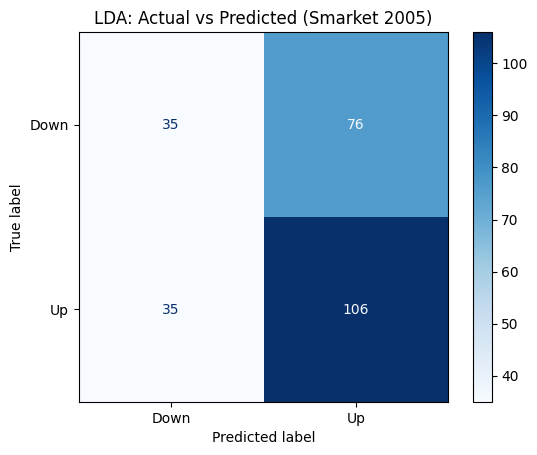

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test, y_pred, labels=lda.classes_)

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lda.classes_)
disp.plot(cmap='Blues')
plt.title("LDA: Actual vs Predicted (Smarket 2005)")
plt.show()

# Quadratic Discriminant Analysis

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Setup (Using Refined Lag1 and Lag2)
# X_train, y_train, X_test, y_test are already defined from previous steps

# 2. Fit QDA
qda = QDA()
qda.fit(X_train, y_train)

# --- PART A: INFERENCE (What the model learned) ---
print("=== INFERENCE: QDA GROUP MEANS ===")
# Note: Means are identical to LDA because they describe the 'centers' of the data
means_df = pd.DataFrame(qda.means_, index=qda.classes_, columns=X_train.columns)
display(means_df)

# --- PART B: PREDICTION (How the model performs) ---
y_pred_qda = qda.predict(X_test)
qda_probs = qda.predict_proba(X_test)

print("\n=== PREDICTION: QDA PERFORMANCE ===")
print(f"QDA Accuracy: {accuracy_score(y_test, y_pred_qda):.4f}")

# Create a comparison table for the first 5 rows
comparison_qda = pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred_qda[:5],
    'Prob_Down': qda_probs[:5, 0].round(4),
    'Prob_Up': qda_probs[:5, 1].round(4)
})
print("\nSample Predictions with Probabilities:")
display(comparison_qda)

=== INFERENCE: QDA GROUP MEANS ===


,Lag1,Lag2
Down,0.042790,0.033894
Up,-0.039546,-0.031325



=== PREDICTION: QDA PERFORMANCE ===
QDA Accuracy: 0.5992

Sample Predictions with Probabilities:


,Actual,Predicted,Prob_Down,Prob_Up
0,Down,Up,0.4873,0.5127
1,Down,Up,0.4759,0.5241
2,Down,Up,0.4637,0.5363
3,Up,Up,0.4739,0.5261
4,Down,Up,0.4903,0.5097
